# 2 - Customer Personality Analysis - Clustering

<img src='https://www.thoughtco.com/thmb/oZSn-Gg35lNg3N8fl5o0Z3gCZ10=/750x0/filters:no_upscale():max_bytes(150000):strip_icc():format(webp)/GettyImages-158317991-58b844535f9b5880809c4739.jpg'>

Bu çalışmada müşteri kişilik ve harcama verilerini kullanarak benzer davranışlara sahip müşteri gruplarını belirleyen bir clustering modeli geliştireceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Veriyi ölçekleme
6. Elbow yöntemi ile küme sayısı seçme
7. KMeans modeli kurma
8. PCA ile görselleştirme
9. Sonuç

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 1. Veriyi Yükleme

In [2]:
# Bu projede Kaggle'dan indirilen müşteri kişilik analizi datasetini Colab üzerinden zip dosyası olarak açıp kullanacağım.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Customer Personality Analysis.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config', 'marketing_campaign.csv', 'drive', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [5]:
# Bu bölümde tab ile ayrılmış csv dosyasını okuyup veri setinin yapısını inceleyeceğim.

In [6]:
file_path = '/content/marketing_campaign.csv'

df = pd.read_csv(file_path, sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
df.shape

(2240, 29)

In [8]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [10]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## 3. Veri Temizleme

In [11]:
# Bu bölümde boş veri kontrolü yapacağım ve Income sütunundaki boş değerleri median ile dolduracağım.

In [12]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [13]:
df['Income'] = df['Income'].fillna(df['Income'].median())
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


## 4. Feature Engineering

In [14]:
# Bu bölümde ID ve tarih sütunlarını düzenleyeceğim, yaşı hesaplayacağım ve kategorik sütunları sayısal hale getireceğim.

In [15]:
df = df.drop('ID', axis=1)
df['Age'] = 2026 - df['Year_Birth']
df = df.drop('Year_Birth', axis=1)
df = df.drop('Dt_Customer', axis=1)

df = pd.get_dummies(df, drop_first=True)
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,0,0,58,635,88,546,172,88,88,...,True,False,False,False,False,False,True,False,False,False
1,46344.0,1,1,38,11,1,6,2,1,6,...,True,False,False,False,False,False,True,False,False,False
2,71613.0,0,0,26,426,49,127,111,21,42,...,True,False,False,False,False,False,False,True,False,False
3,26646.0,1,0,26,11,4,20,10,3,5,...,True,False,False,False,False,False,False,True,False,False
4,58293.0,1,0,94,173,43,118,46,27,15,...,False,False,True,False,False,True,False,False,False,False


## 5. Veriyi Ölçekleme

In [16]:
# Bu bölümde clustering öncesi tüm değişkenleri aynı ölçeğe getireceğim.

In [17]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)
x_scaled[:5]

array([[ 2.35695837e-01, -8.25217650e-01, -9.29894379e-01,
         3.07039263e-01,  9.83781265e-01,  1.55157698e+00,
         1.67970233e+00,  2.46214705e+00,  1.47650010e+00,
         8.43206907e-01,  3.49413941e-01,  1.40930394e+00,
         2.51089024e+00, -5.50784790e-01,  6.93903739e-01,
        -2.80140277e-01, -2.83830188e-01, -2.80140277e-01,
        -2.62111217e-01, -1.16510346e-01, -9.72816653e-02,
         0.00000000e+00,  0.00000000e+00,  2.38884634e+00,
         9.85344730e-01, -1.57170777e-01,  9.93769410e-01,
        -4.44815650e-01, -5.26384800e-01, -3.66207838e-02,
        -3.39908589e-01, -7.92405816e-01,  1.91485422e+00,
        -5.91098630e-01, -1.88676192e-01, -2.98940638e-02],
       [-2.35454185e-01,  1.03255877e+00,  9.06934024e-01,
        -3.83664176e-01, -8.70479481e-01, -6.36301155e-01,
        -7.13225407e-01, -6.50449253e-01, -6.31503178e-01,
        -7.29005787e-01, -1.68236342e-01, -1.11040937e+00,
        -5.68719619e-01, -1.16612540e+00, -1.30463472e-

## 6. Elbow Yöntemi ile Küme Sayısı Seçme

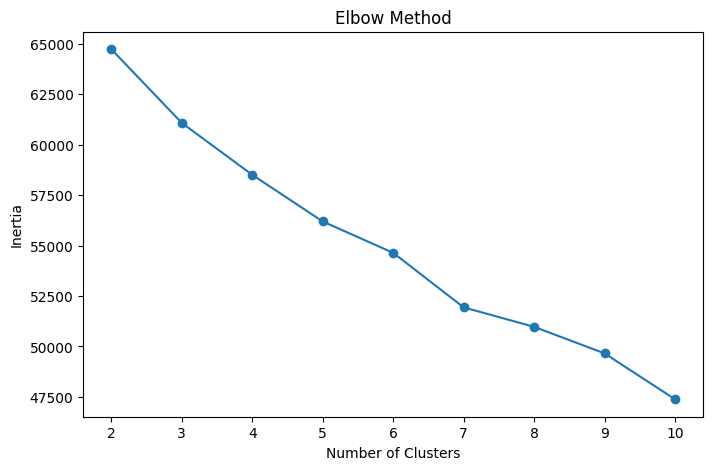

In [19]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

## 7. KMeans Modeli Kurma

In [20]:
# Bu bölümde seçilen küme sayısı ile KMeans modelini kuracağım ve segmentleri oluşturacağım.

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_scaled)

df['Cluster'] = clusters
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,False,False,False,False,False,True,False,False,False,1
1,46344.0,1,1,38,11,1,6,2,1,6,...,False,False,False,False,False,True,False,False,False,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,False,False,False,False,False,False,True,False,False,1
3,26646.0,1,0,26,11,4,20,10,3,5,...,False,False,False,False,False,False,True,False,False,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,False,True,False,False,True,False,False,False,False,2


In [22]:
silhouette = silhouette_score(x_scaled, clusters)
silhouette

np.float64(0.1187960813030892)

## 8. PCA ile Görselleştirme

In [23]:
# Bu bölümde kümeleri iki boyutta görselleştirerek segmentlerin ayrışmasını inceleyeceğim.

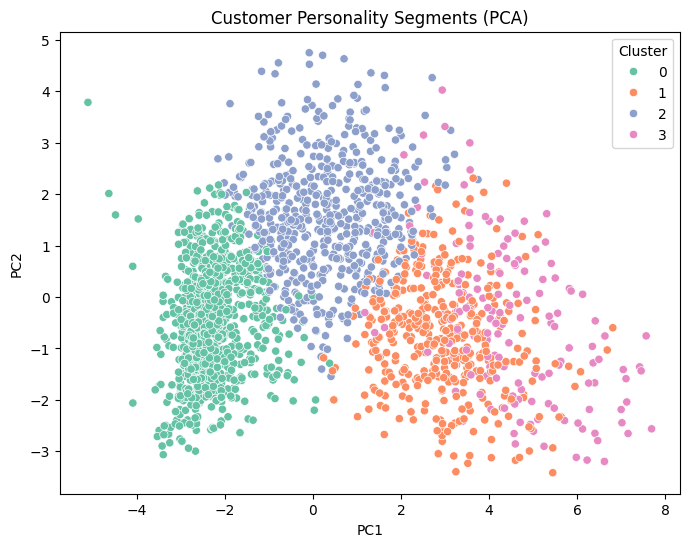

In [24]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2')
plt.title('Customer Personality Segments (PCA)')
plt.show()

## 9. Sonuç

Bu projede müşteri kişilik ve harcama davranışlarına göre segmentasyon yapmak için KMeans clustering yöntemi kullanıldı. Elde edilen sonuçlara göre en uygun küme sayısı 4 oldu ve model 0.1188 silhouette score değeri elde etti.
